In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.dates import DateFormatter

In [35]:
df = pd.read_csv('../../outputs/HVAC_NewData_Analysis_Data/cleaned_terminal_units.csv', parse_dates=['time'])
df = df.sort_values(['VAV_ID', 'time'])

In [36]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [37]:
# =============================================
# 1. Temporal feature extraction
# =============================================
df['hour'] = df['time'].dt.hour
df['dayofweek'] = df['time'].dt.dayofweek  # 0=周一
df['month'] = df['time'].dt.month
df['season'] = df['month'].apply(lambda x: 'Winter' if x in [12,1,2] else 
                                'Spring' if x in [3,4,5] else
                                'Summer' if x in [6,7,8] else 'Fall')


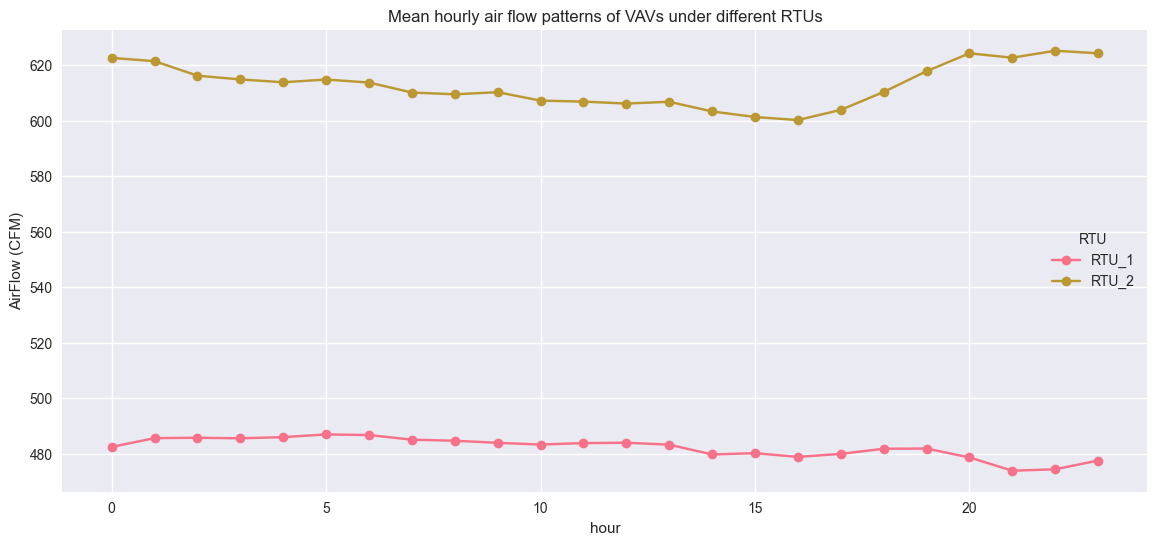

In [38]:
# =============================================
# 2. 周期性模式分析
# =============================================
# 2.1 小时级模式
hourly_flow = df.groupby(['hour', 'RTU'])['AirFlow'].mean().unstack()

plt.figure(figsize=(14,6))
hourly_flow.plot(marker='o', ax=plt.gca())
plt.title("Mean hourly air flow patterns of VAVs under different RTUs")
plt.ylabel("AirFlow (CFM)")
plt.grid(True)
# plt.close()
plt.show()

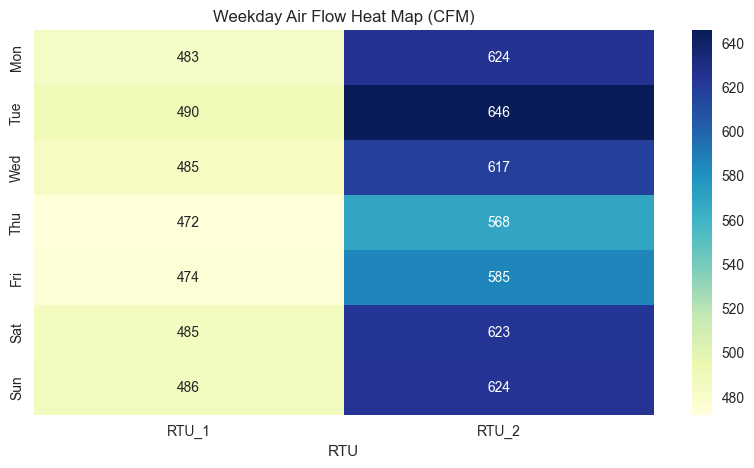

In [39]:
# 2.2 周几模式
weekday_flow = df.groupby(['dayofweek', 'RTU'])['AirFlow'].mean().unstack()
weekday_flow.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

plt.figure(figsize=(10,5))
sns.heatmap(weekday_flow, cmap="YlGnBu", annot=True, fmt=".0f")
plt.title("Weekday Air Flow Heat Map (CFM)")
# plt.close()
plt.show()

In [40]:
# =============================================
# 3. 非工作时间能耗分析
# =============================================
# 定义工作时间 (8AM-6PM)
df['is_workhour'] = ((df['hour'] >= 8) & (df['hour'] <= 18)).astype(int)

# 3.1 非工作时段基线
non_work_stats = df[df['is_workhour']==0].groupby('VAV_ID')['AirFlow'].agg(
    ['mean', 'std', 'max']).sort_values('mean', ascending=False)

print("Off-Hours Air Flow Statistics (Top10 High Energy VAVs).")
display(non_work_stats.head(10))

Off-Hours Air Flow Statistics (Top10 High Energy VAVs).


,mean,std,max
VAV_ID,,,
K,1043.589364,337.542351,1903.460000
FF,949.693119,192.088867,1471.916667
JJ,930.953995,191.571435,1243.073333
DD,926.511629,46.291375,1043.196667
CC,899.496468,161.785951,1123.713333
B,863.185711,175.892849,959.853333
BB,858.919499,45.426075,1126.536667
II,832.032086,182.308325,1217.646667
D,831.632591,1.895663,850.376667


In [41]:
# 3.2 Abnormal nighttime energy consumption detection
night_flow_threshold = non_work_stats['mean'].quantile(0.75) + 1.5*(non_work_stats['mean'].quantile(0.75)-non_work_stats['mean'].quantile(0.25))
abnormal_night = non_work_stats[non_work_stats['mean'] > night_flow_threshold]

print(f"\nDetected {len(abnormal_night)} VAVs with abnormal energy consumption during non-working hours.")
if not abnormal_night.empty:
    display(abnormal_night)

    case_vav = abnormal_night.index[0]
    case_data = df[(df['VAV_ID']==case_vav)&(df['time'].dt.date==df['time'].dt.date.max())]  # Last day's data

    plt.figure(figsize=(14,5))
    plt.plot(case_data['time'], case_data['AirFlow'], label='AirFlow')
    plt.axhline(y=night_flow_threshold, color='r', linestyle='--', label='异常阈值')
    plt.fill_between(case_data['time'], 0, case_data['AirFlow'], 
                     where=(case_data['hour'] < 8)|(case_data['hour'] > 18),
                     color='orange', alpha=0.3, label='Out-of-hours')
    plt.title(f"Example of an exception VAV ({case_vav} - last 24 hours))")
    plt.legend()
    plt.show()
else:
    print("VAVs that do not detect abnormal energy consumption during non-operating hours skip the visualization step.")


Detected 0 VAVs with abnormal energy consumption during non-working hours.
VAVs that do not detect abnormal energy consumption during non-operating hours skip the visualization step.


<Figure size 1200x600 with 0 Axes>

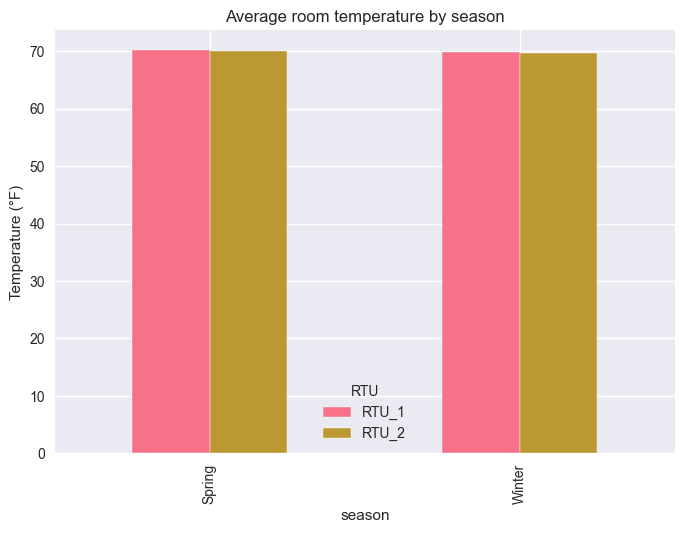

In [42]:
# =============================================
# 4. 季节性能效对比
# =============================================
# 4.1 季节性温度控制
seasonal_temp = df.groupby(['season', 'RTU']).agg({
    'RmTemp': ['mean', 'std'],
    'DschAirTemp': lambda x: (x > 75).mean()  # 高温送风频率
}).unstack()

plt.figure(figsize=(12,6))
seasonal_temp['RmTemp']['mean'].plot(kind='bar')
plt.title("Average room temperature by season")
plt.ylabel("Temperature (°F)")
plt.show()

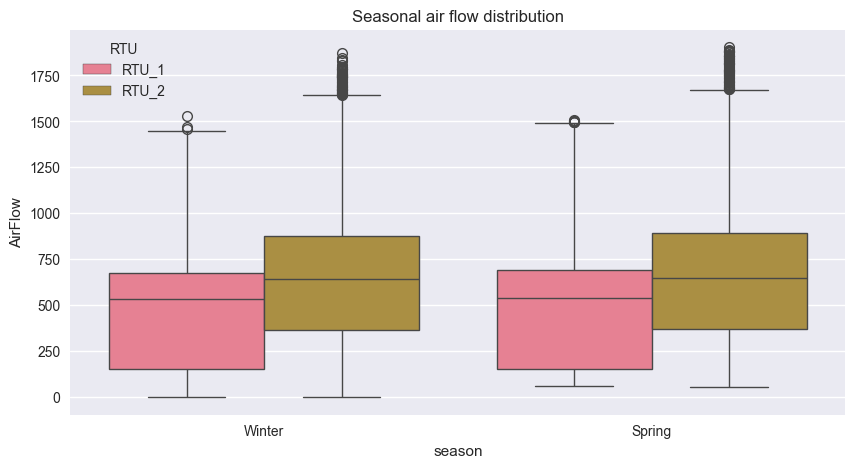

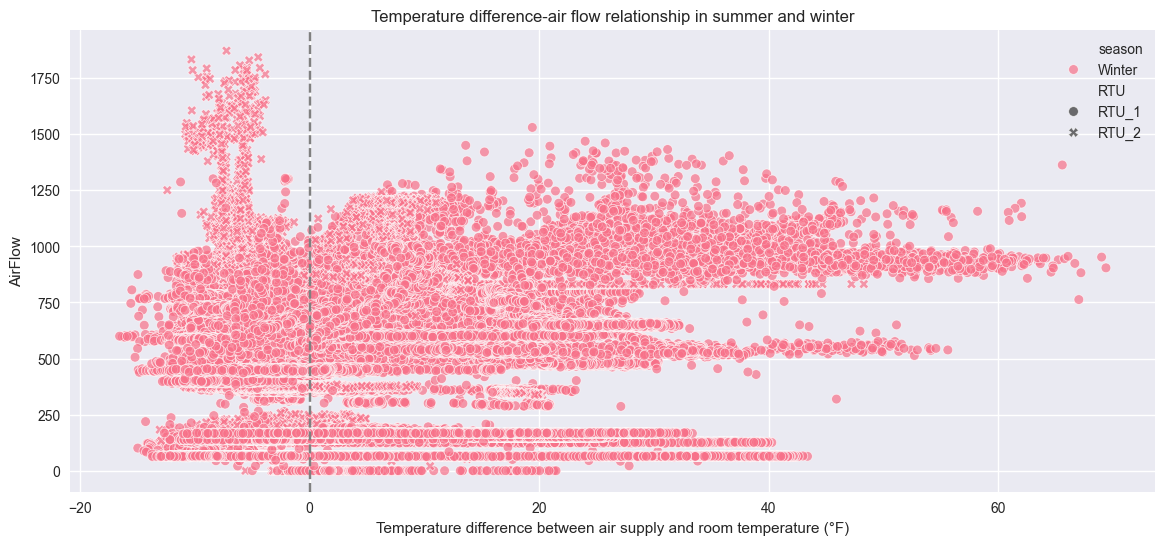

In [43]:
# 4.2 季节性能耗强度
df['energy_proxy'] = df['AirFlow'] * df['DschAirTemp']  # 简化的能耗代理指标
seasonal_energy = df.groupby(['season', 'RTU'])['energy_proxy'].mean().unstack()

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='season', y='AirFlow', hue='RTU')
plt.title("Seasonal air flow distribution")
plt.show()


# 4.3 夏季vs冬季深度对比
summer_winter = df[df['season'].isin(['Summer', 'Winter'])].copy()
summer_winter['temp_diff'] = summer_winter['DschAirTemp'] - summer_winter['RmTemp']

plt.figure(figsize=(14,6))
sns.scatterplot(data=summer_winter, x='temp_diff', y='AirFlow', 
                hue='season', style='RTU', alpha=0.7)
plt.axvline(0, color='gray', linestyle='--')
plt.title("Temperature difference-air flow relationship in summer and winter")
plt.xlabel("Temperature difference between air supply and room temperature (°F)")
plt.show()

In [46]:
# =============================================
# 5. 保存分析结果
# =============================================
# 生成季节性报告
season_report = df.groupby('season').agg({
    'AirFlow': ['mean', 'median'],
    'DmprPos': ['mean', 'std'],
    'total_outliers': 'sum'
})
season_report.to_csv('../../outputs/HVAC_NewData_Analysis_Results/3.seasonal_performance_report.csv')

print("\nSeasonal analysis completed")



Seasonal analysis completed
